In [ ]:
!pip install matplotlib
!pip install tqdm
!pip install scikit-learn
!pip install ucimlrepo 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from ucimlrepo import fetch_ucirepo

from ap_ood import APOOD
from ap_ood.utils.plot_util import plot_histograms

# AP-OOD Multiple Instance Learning (MIL) Example

This example demonstrates the OOD detection capabilities of our method on the [MUSK dataset](https://archive.ics.uci.edu/dataset/74/musk+version+1):

> This dataset describes a set of 92 molecules of which 47 are judged by human experts to be musks and the remaining 45 molecules are judged to be non-musks.  The goal is to learn to predict whether new molecules will be musks or non-musks.  However, the 166 features that describe these molecules depend upon the exact shape, or conformation, of the molecule.  Because bonds can rotate, a single molecule can adopt many different shapes.  To generate this data set, the low-energy conformations of the molecules were generated and then filtered to remove highly similar conformations. This left 476 conformations. Then, a feature vector was extracted that describes each conformation.
>
> This many-to-one relationship between feature vectors and molecules is called the "multiple instance problem".  When learning a classifier for this data, the classifier should classify a molecule as "musk" if ANY of its conformations is classified as a musk.  A molecule should be classified as "non-musk" if NONE of its conformations is classified as a musk.

We will perform OOD detection by training only the positive examples (musks), and we want to be able to detect the negative examples (non-musks) as OOD.

## Loading and Pre-Processing

In [2]:
# fetch
musk1 = fetch_ucirepo(id=74)          # MUSK 2 dataset
df = musk1.data.features              # 166 numeric columns + IDs
labels = musk1.data.targets['class']  # 0 = non‑musk, 1 = musk

# group into MIL bags
bags = df.join(labels).groupby('molecule_name')
X_bags = [bag.drop(columns=['class']) for _, bag in bags]  # list of DataFrames
y = np.array([int(bag['class'].max()) for _, bag in bags])      # bag label

print(len(X_bags), "bags ready for MIL:", sum(y), "positive,", len(y)-sum(y), "negative")

92 bags ready for MIL: 47 positive, 45 negative


In [3]:
X_bags[0]

,molecule_name,conformation_name,f1,f2,f3,f4,f5,f6,f7,f8,...,f157,f158,f159,f160,f161,f162,f163,f164,f165,f166
0,MUSK-188,188_1+1,42,-198,-109,-75,-117,11,23,-88,...,-238,-74,-129,-120,-38,30,48,-37,6,30
1,MUSK-188,188_1+2,42,-191,-142,-65,-117,55,49,-170,...,-238,-302,60,-120,-39,31,48,-37,5,30
2,MUSK-188,188_1+3,42,-191,-142,-75,-117,11,49,-161,...,-238,-73,-127,-120,-38,30,48,-37,5,31
3,MUSK-188,188_1+4,42,-198,-110,-65,-117,55,23,-95,...,-238,-302,60,-120,-39,30,48,-37,6,30


To characterize the Multiple Instance Learning (MIL) problem structure, we first analyze the distribution of bag sizes (i.e., the number of conformations per molecule). This visualization highlights the variability in the number of bags the aggregation mechanism must accomodate.

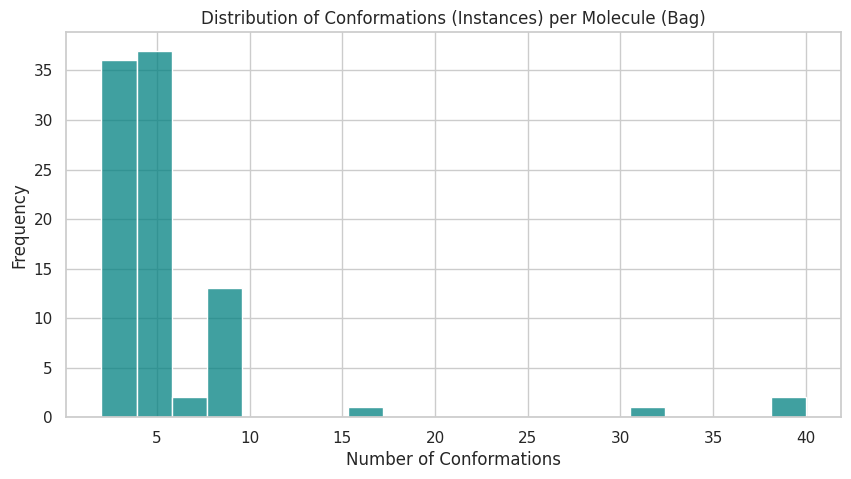

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Calculate bag sizes
bag_sizes = [len(bag) for bag in X_bags]

plt.figure(figsize=(10, 5))
sns.histplot(bag_sizes, bins=20, color='teal')
plt.title("Distribution of Conformations (Instances) per Molecule (Bag)")
plt.xlabel("Number of Conformations")
plt.ylabel("Frequency")
plt.show()

In [5]:
def convert_bags_to_arrays(X_bags):
    max_length = max(len(bag) for bag in X_bags)
    n_features = X_bags[0].shape[1] - 2
    if not all(bag.shape[1] - 2 == n_features for bag in X_bags):
        raise ValueError('All instances must have the same number of features.')
    X = np.zeros([len(X_bags), max_length, n_features])
    mask = np.zeros([len(X_bags), max_length])
    
    for i, bag in enumerate(X_bags):
        for j, instance in bag.reset_index(drop=True).iterrows():
            X[i, j] = instance.iloc[2:].to_numpy(dtype='float32')
            mask[i, j] = 1
    
    return X, mask
    
X, mask = convert_bags_to_arrays(X_bags)
scaler = StandardScaler()
scaler.fit(X[y==1].reshape([-1, X.shape[-1]]))
X = scaler.transform(X.reshape([-1, X.shape[-1]])).reshape(X.shape)

X = torch.tensor(X).float()
mask = torch.tensor(mask).bool()
y = torch.tensor(y)
print(list(X.shape), '[Molecule, Conformation, Feature]')

[92, 40, 166] [Molecule, Conformation, Feature]


## Training

In [6]:
model = APOOD(
    feature_dim=166,
    n_heads=128,
    n_queries=2,
    beta=1.,
    similarity='dot',
)

In [7]:
n_steps = 500

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=0.)  # weight_decay=0. keeps the parameters from converging to the trivial minimum at 0.

X_pos, X_neg = X[y==1], X[y==0]
mask_pos, mask_neg = mask[y==1], mask[y==0]

# Split positivies in training and test split.
X_pos_train, X_pos_test, mask_pos_train, mask_pos_test = train_test_split(X_pos, mask_pos, test_size=0.2)

for _ in tqdm(range(n_steps)):
    ood_scores = model(X_pos_train, mask_pos_train)  # supply bags / sequences and masks (if applicable) to the model
    loss = torch.mean(ood_scores)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# After the model is trained, we supply it with the ID data once again so that it can fit the mean
model.partial_fit_mean(X_pos_train, mask_pos_train)

# This also works when supplying the ID data in mini-batches
model.reset_mean()
batch_size = 4
for i in range(0, len(X_pos_train), batch_size):
    X_batch = X_pos_train[i:i+batch_size]
    mask_batch = mask_pos_train[i:i+batch_size]
    model.partial_fit_mean(X_batch, mask_batch)

100%|██████████| 500/500 [00:04<00:00, 108.16it/s]


## Evaluation
### Visualize OOD Scores for Positives (Test) and Negatives

Now that the model is trained, let's look at the scores it assigns to the test data.

Since the model only saw "Musks" (positive examples) during training, it should recognize them as normal and give them high scores (=low distances). Conversely, the "Non-Musks" (negative examples) should look unfamiliar to the model, resulting in much lower scores (=higher distances).

Ideally, we want to see a clear separation between the Positive (blue) and Negative (orange) distributions.

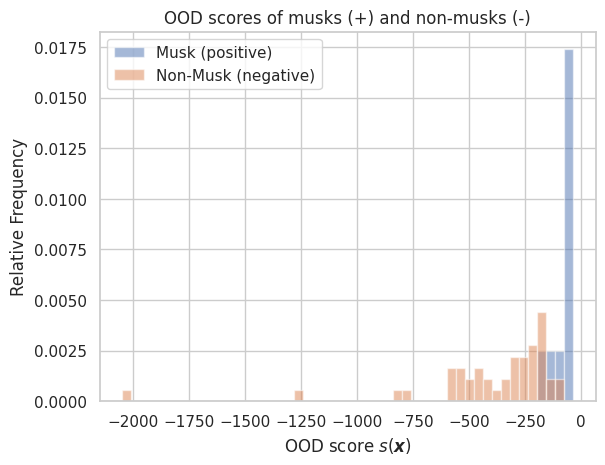

In [8]:
model.eval()  # model.eval() will make the model use the mean fitted by calling partial_fit_mean

id_scores = -model(X_pos_test, mask_pos_test).detach()
ood_scores = -model(X_neg, mask_neg).detach()
plot_histograms([id_scores.detach(), ood_scores.detach()], ['Musk (positive)', 'Non-Musk (negative)'], bins=50, density=True)
plt.legend()
plt.xlabel('OOD score $s(\\boldsymbol{x})$')
plt.title('OOD scores of musks (+) and non-musks (-)')
plt.show()

### ROC curve

We use the Area Under the Receiver Operating Characteristic (AUROC) to quantify how well our model distinguishes between Musks and Non-Musks.

Since we obtained an AUROC of 0.98, this indicates the model is highly effective.

We also plot the ROC curve below to visualize the trade-off for detecting OOD examples at different thresholds for the true positive rate.

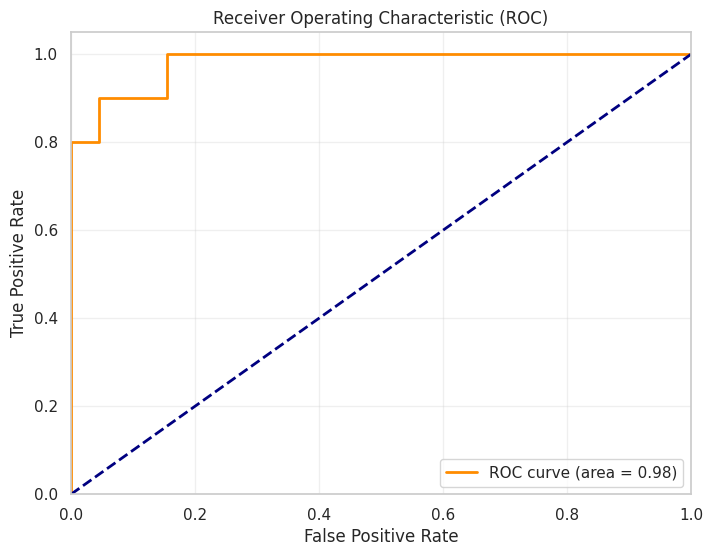

In [ ]:
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve

labels = np.concatenate([np.zeros_like(ood_scores), np.ones_like(id_scores)])
scores = np.concatenate([ood_scores, id_scores])

fpr, tpr, _ = roc_curve(labels, scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(labels, scores):.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()